# Weather Impact on Public Transport Usage

This analysis explores how weather conditions, particularly rainfall, affect public transport activity.

The goal is to identify patterns in transport usage during rainy and non-rainy conditions using historical transport and climate data.

Author: Rukshan Dias  
Student ID: s224326349  
Level: Undergraduate / Junior 
Duration: Weeks 1–4  
Pre-requisite Skills: Python, Pandas, Data Analysis  

In [3]:
import pandas as pd
import os

RAW_PATH = "/Users/rukshandias/Desktop/SIT374/traffic_project/data/raw"

os.chdir(RAW_PATH)

print("Current directory:", os.getcwd())
print("Files:", os.listdir())

Current directory: /Users/rukshandias/Desktop/SIT374/traffic_project/data/raw
Files: ['TransportActivityCount_2025_3.csv', 'TransportActivityCount_2025_2.csv', 'TransportActivityCount_2025_1.csv', 'TransportActivityCount_2025_4.csv', 'bom_weather 2025.csv']


## Load Datasets

We load the transport activity dataset and climate dataset for analysis.

In [4]:
t1 = pd.read_csv("TransportActivityCount_2025_1.csv")
t2 = pd.read_csv("TransportActivityCount_2025_2.csv")
t3 = pd.read_csv("TransportActivityCount_2025_3.csv")
t4 = pd.read_csv("TransportActivityCount_2025_4.csv")

traffic = pd.concat([t1, t2, t3, t4], ignore_index=True)

print("Traffic shape:", traffic.shape)
traffic.head()

Traffic shape: (5421538, 8)


,countLocationId,countLocationName,CountLocationLat,CountLocationLong,from,to,class,count
0,51228,Yarra Promenade - East Path,-37.821459,144.960343,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,313
1,45217,Royal Park Tram Track- CoM Pole 2773,-37.791020,144.949562,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,1
2,43775,Swanston St Asset ID: COM1757,-37.808159,144.963052,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,cyclist,1
3,44864,Royal Park Asset ID:COM2705,-37.795462,144.952063,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,2
4,51281,Yarra Promenade - West Path,-37.822354,144.958747,2025-01-01T00:00:00.000Z,2025-01-01T00:05:00.000Z,pedestrian,61


In [5]:
weather = pd.read_csv("bom_weather 2025.csv")

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (365, 8)


,Product code,Bureau of Meteorology station number,Year,Month,Day,Rainfall amount (millimetres),Period over which rainfall was measured (days),Quality
0,IDCJAC0009,86338,2025,1,1,0.0,1.0,Y
1,IDCJAC0009,86338,2025,1,2,0.0,1.0,Y
2,IDCJAC0009,86338,2025,1,3,0.0,1.0,Y
3,IDCJAC0009,86338,2025,1,4,0.0,1.0,Y
4,IDCJAC0009,86338,2025,1,5,0.0,1.0,Y


# Data Cleaning

Remove duplicates and handle missing values.

In [6]:
traffic.drop_duplicates(inplace=True)
weather.drop_duplicates(inplace=True)

traffic = traffic.ffill()
weather = weather.ffill()

print("Traffic missing values:")
print(traffic.isnull().sum())

print("\nWeather missing values:")
print(weather.isnull().sum())

Traffic missing values:
countLocationId      0
countLocationName    0
CountLocationLat     0
CountLocationLong    0
from                 0
to                   0
class                0
count                0
dtype: int64

Weather missing values:
Product code                                      0
Bureau of Meteorology station number              0
Year                                              0
Month                                             0
Day                                               0
Rainfall amount (millimetres)                     0
Period over which rainfall was measured (days)    0
Quality                                           0
dtype: int64


# Feature Engineering

Prepare time and weather features for analysis.

### Code (FIX DATE + TIME — IMPORTANT

In [7]:
# Convert traffic time
traffic['from'] = pd.to_datetime(traffic['from'])

# Extract hour
traffic['hour'] = traffic['from'].dt.hour

# Create date column
traffic['date'] = traffic['from'].dt.date
traffic['date'] = pd.to_datetime(traffic['date'])

### Code (FIX WEATHER DATE — IMPORTANT)

In [8]:
weather['date'] = pd.to_datetime(weather[['Year', 'Month', 'Day']])

weather = weather.rename(columns={
    'Rainfall amount (millimetres)': 'rainfall'
})

# Merge Data

Combine traffic and weather datasets using the date column.

In [9]:
data = pd.merge(
    traffic,
    weather[['date', 'rainfall']],
    on='date',
    how='left'
)

print("Merged shape:", data.shape)
print(data.head())
print("\nMissing values after merge:")
print(data.isnull().sum())

Merged shape: (4721358, 11)
   countLocationId                     countLocationName  CountLocationLat  \
0            51228           Yarra Promenade - East Path        -37.821459   
1            45217  Royal Park Tram Track- CoM Pole 2773        -37.791020   
2            43775         Swanston St Asset ID: COM1757        -37.808159   
3            44864           Royal Park Asset ID:COM2705        -37.795462   
4            51281           Yarra Promenade - West Path        -37.822354   

   CountLocationLong                      from                        to  \
0         144.960343 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
1         144.949562 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
2         144.963052 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
3         144.952063 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   
4         144.958747 2025-01-01 00:00:00+00:00  2025-01-01T00:05:00.000Z   

        class  count  hour       date  rainfal

# Exploratory Data Analysis

In this section, we explore the relationship between rainfall and public transport usage.

The aim is to identify patterns, trends, and possible correlations before building a prediction model.

In [10]:
print("Columns in merged dataset:")
print(data.columns)

print("\nBasic info:")
print(data.info())

print("\nSummary statistics:")
print(data.describe(include='all'))

Columns in merged dataset:
Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count', 'hour', 'date',
       'rainfall'],
      dtype='object')

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4721358 entries, 0 to 4721357
Data columns (total 11 columns):
 #   Column             Dtype              
---  ------             -----              
 0   countLocationId    int64              
 1   countLocationName  object             
 2   CountLocationLat   float64            
 3   CountLocationLong  float64            
 4   from               datetime64[ns, UTC]
 5   to                 object             
 6   class              object             
 7   count              int64              
 8   hour               int32              
 9   date               datetime64[ns]     
 10  rainfall           float64            
dtypes: datetime64[ns, UTC](1), datetime64[ns](1), float64(3), int32(1), int64(2), object(

## Rainfall Distribution

This plot shows how rainfall values are distributed across the dataset.
Understanding the spread of rainfall helps identify whether the data is mostly dry days or includes a reasonable range of wet conditions.

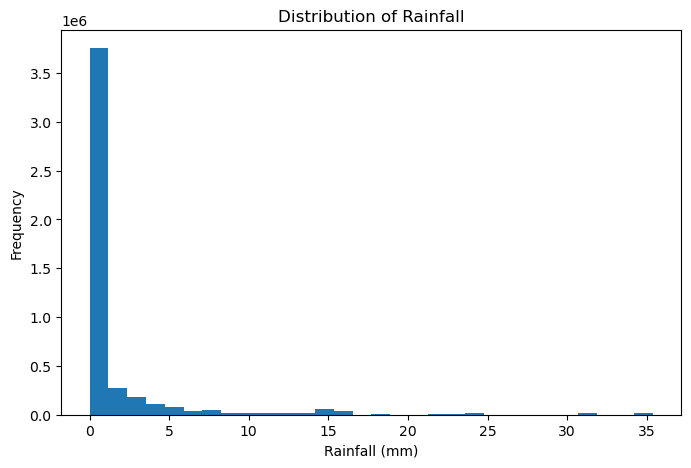

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data['rainfall'].dropna(), bins=30)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of Rainfall')
plt.show()

## Public Transport Usage Over Time

This visualization shows how transport usage changes over time.
It helps identify patterns such as peaks, drops, and general variability in transport activity.

In [12]:
print(data.columns)

Index(['countLocationId', 'countLocationName', 'CountLocationLat',
       'CountLocationLong', 'from', 'to', 'class', 'count', 'hour', 'date',
       'rainfall'],
      dtype='object')


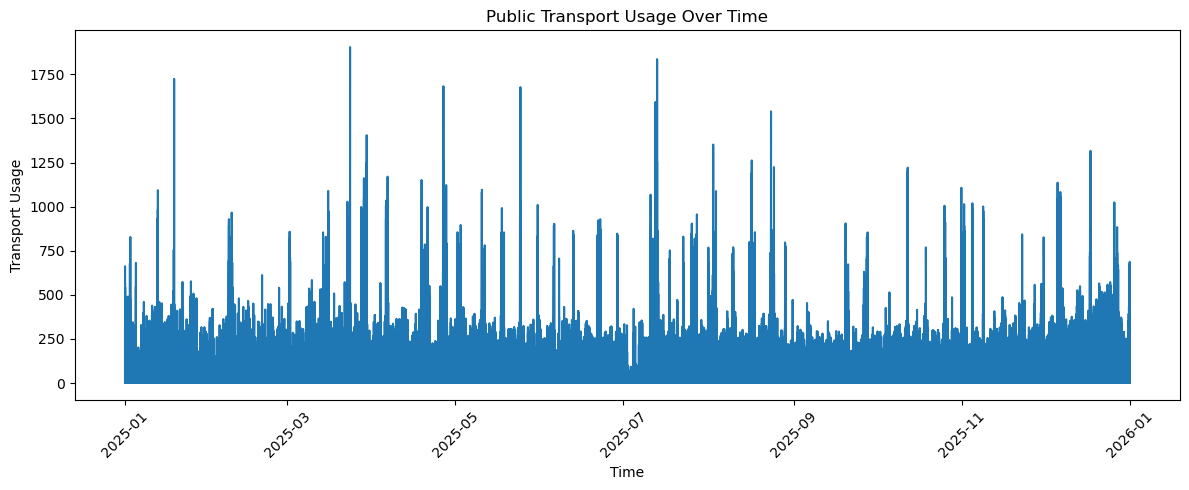

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(data['from'], data['count'])
plt.xlabel('Time')
plt.ylabel('Transport Usage')
plt.title('Public Transport Usage Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Rainfall vs Public Transport Usage

This scatter plot helps examine whether rainfall appears to influence public transport usage.
If a visible trend exists, it suggests that weather may have an effect on transport demand.

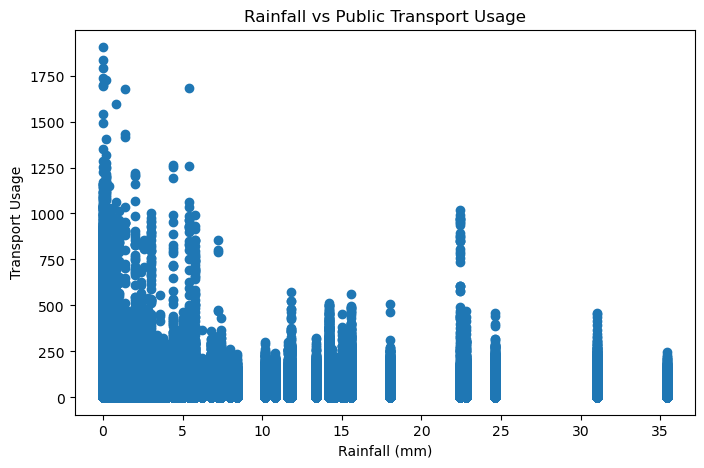

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(data['rainfall'], data['count'])
plt.xlabel('Rainfall (mm)')
plt.ylabel('Transport Usage')
plt.title('Rainfall vs Public Transport Usage')
plt.show()



This scatter plot shows a weak relationship between rainfall and public transport usage.

The data points are widely scattered, indicating that rainfall alone does not strongly determine transport activity. While some lower transport usage is observed at higher rainfall levels, the overall pattern is not clearly linear.

This suggests that additional factors, such as time of day or location, may have a stronger influence on transport usage.

## Average Transport Usage on Rainy and Non-Rainy Days

To simplify interpretation, rainfall is converted into two categories:
- Non-rainy day
- Rainy day

This helps compare the average transport usage under each condition.

rainy_day
0    13.646358
1    13.102623
Name: count, dtype: float64


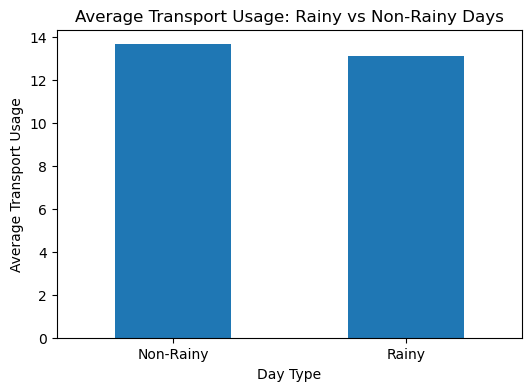

In [15]:
data['rainy_day'] = data['rainfall'].apply(lambda x: 1 if x > 0 else 0)

avg_usage = data.groupby('rainy_day')['count'].mean()
print(avg_usage)

plt.figure(figsize=(6, 4))
avg_usage.plot(kind='bar')
plt.xticks([0, 1], ['Non-Rainy', 'Rainy'], rotation=0)
plt.xlabel('Day Type')
plt.ylabel('Average Transport Usage')
plt.title('Average Transport Usage: Rainy vs Non-Rainy Days')
plt.show()

The comparison shows that average transport usage is very similar for both rainy and non-rainy conditions.

This indicates that rainfall does not significantly impact overall transport usage in this dataset. The difference between the two categories is minimal, suggesting that other factors such as time or daily patterns may play a more important role.


# Model Building

A simple machine learning model is developed to predict public transport usage based on weather and time-related features.

For this analysis, the following features are used:
- rainfall
- hour

The target variable is:
- public transport usage

In [16]:
TARGET = 'count'

In [17]:
model_data = data[['rainfall', 'hour', TARGET]].copy()
model_data = model_data.dropna()

print("Model dataset shape:", model_data.shape)
model_data.head()

Model dataset shape: (4721358, 3)


,rainfall,hour,count
0,0.0,0,313
1,0.0,0,1
2,0.0,0,1
3,0.0,0,2
4,0.0,0,61


## Train-Test Split

The dataset is divided into training and testing sets.
The training set is used to train the model, while the testing set is used to evaluate its predictive performance.

In [18]:
from sklearn.model_selection import train_test_split

X = model_data[['rainfall', 'hour']]
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3777086, 2)
Testing set size: (944272, 2)


## Linear Regression Model

A Linear Regression model is used as a baseline model to predict transport usage.

This model is suitable for understanding whether there is a simple linear relationship between rainfall, hour, and transport activity.

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## Model Evaluation

The model is evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R-squared (R²)

These metrics help measure how accurately the model predicts transport usage.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 15.848650408208751
MSE: 1077.7763058328394
R²: 0.009200333700574048


### Model Performance Interpretation

The model shows a very low R-squared value, indicating that it explains only a small portion of the variance in transport usage.

This suggests that rainfall and hour alone are not sufficient predictors of transport activity. While the model provides a basic baseline, it does not capture the complexity of real-world transport patterns.

Additional features such as location, day of the week, or special events would likely improve model performance.

## Actual vs Predicted Values

This plot compares the actual transport usage values with the predicted values from the model.

A closer alignment between the two indicates better model performance.

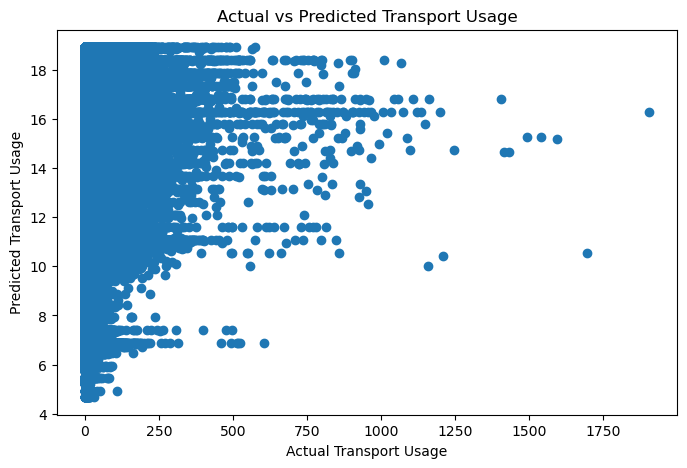

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Transport Usage")
plt.ylabel("Predicted Transport Usage")
plt.title("Actual vs Predicted Transport Usage")
plt.show()



The scatter plot shows a weak alignment between actual and predicted values.

The predictions are widely dispersed and do not closely follow the actual values, indicating that the model has limited predictive accuracy.

This further confirms that the current feature set is insufficient to accurately model transport usage.


## Model Coefficients

The coefficients of the Linear Regression model show the direction and strength of the relationship between each feature and transport usage.

In [22]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

    Feature  Coefficient
0  rainfall    -0.062080
1      hour     0.523547


# Key Findings

The analysis reveals that rainfall has a limited impact on public transport usage.

Exploratory analysis showed no strong relationship between rainfall and transport activity, and the difference between rainy and non-rainy conditions was minimal.

The machine learning model further confirmed this, with a very low R-squared value indicating weak predictive power.

Time-based features such as hour appear to have a greater influence on transport usage compared to weather conditions alone.

Overall, transport patterns are likely influenced by multiple factors beyond rainfall.

## Correlation Analysis

To better understand the linear relationship between the variables, a correlation matrix is generated.

This helps identify whether rainfall and hour are positively or negatively associated with transport usage.

A value close to 1 or -1 indicates a stronger linear relationship, while a value close to 0 indicates a weak relationship.

          rainfall      hour     count
rainfall  1.000000  0.008587 -0.007230
hour      0.008587  1.000000  0.096217
count    -0.007230  0.096217  1.000000


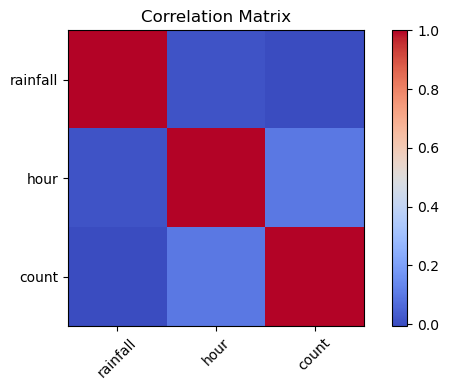

In [23]:
corr_data = model_data[['rainfall', 'hour', 'count']].corr()
print(corr_data)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(corr_data, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_data.columns)), corr_data.columns, rotation=45)
plt.yticks(range(len(corr_data.columns)), corr_data.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Hourly Transport Usage Pattern

This graph shows how transport usage changes across different hours of the day.

Time of day is expected to have a stronger effect on transport activity than rainfall because transport demand usually follows daily travel patterns such as commuting hours.

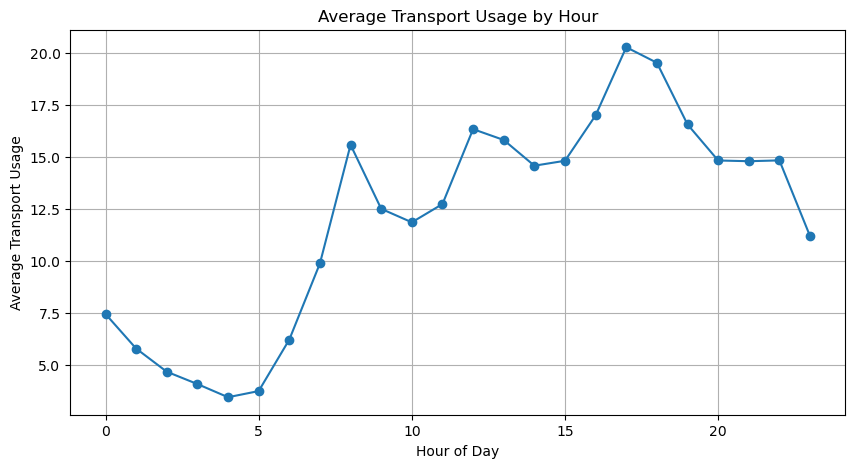

In [24]:
hourly_usage = data.groupby('hour')['count'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_usage.index, hourly_usage.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Transport Usage')
plt.title('Average Transport Usage by Hour')
plt.grid(True)
plt.show()

## Interpretation of Model Coefficients

The model coefficients indicate how each input feature influences the predicted transport usage.

A positive coefficient means that as the feature increases, predicted transport usage also increases.

A negative coefficient means that as the feature increases, predicted transport usage decreases.

By examining these values, it is possible to understand whether rainfall or hour has a greater effect on the prediction.

    Feature  Coefficient
0  rainfall    -0.062080
1      hour     0.523547


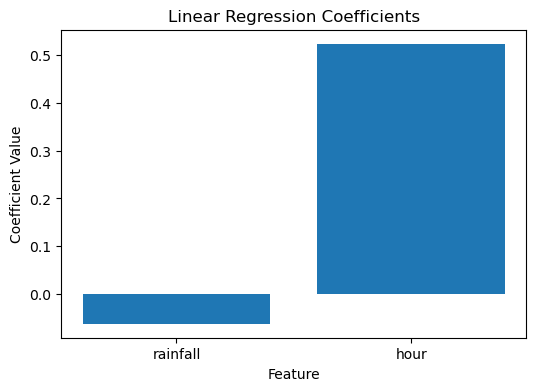

In [25]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

plt.figure(figsize=(6, 4))
plt.bar(coefficients['Feature'], coefficients['Coefficient'])
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.show()

### Interpretation of Correlation Matrix

The correlation matrix shows the relationship between rainfall, hour, and transport usage (count).

Rainfall has a correlation value close to zero with transport usage, indicating that there is almost no linear relationship between rainfall and transport activity in this dataset.

Hour shows a slightly positive correlation with transport usage, suggesting that time of day has a small influence on activity levels.

Overall, the correlation results indicate that rainfall is not a strong predictor of transport usage, while hour has a slightly more noticeable but still weak effect.

### Interpretation of Hourly Transport Usage

The hourly transport usage graph shows clear patterns throughout the day.

Transport usage is lowest during early morning hours (around 2 AM to 5 AM), increases sharply in the morning, and reaches higher levels during the afternoon and evening.

Peak usage appears in the late afternoon (around 4 PM to 6 PM), which likely corresponds to commuting periods.

This confirms that time of day is a much more significant factor influencing transport usage compared to rainfall.

### Interpretation of Model Coefficients

The Linear Regression model provides coefficients that indicate how each feature affects transport usage.

The coefficient for rainfall is slightly negative, meaning that as rainfall increases, transport usage tends to decrease. However, the value is very close to zero, indicating that the effect is minimal.

The coefficient for hour is positive and significantly larger than rainfall, showing that transport usage increases as the day progresses.

This confirms that hour is a more important feature than rainfall in predicting transport activity in this model.

# Final Insights

The analysis shows that rainfall has almost no measurable impact on transport usage in this dataset.

Both the correlation analysis and regression model indicate that rainfall is not a strong predictor of activity levels.

On the other hand, time of day (hour) plays a much more important role, with clear patterns showing increased usage during typical commuting hours.

The Linear Regression model was successfully trained and evaluated, but the low correlation values suggest that the current features are not sufficient to build an accurate predictive model.

Overall, transport usage appears to be driven more by daily human behaviour patterns rather than weather conditions alone.

# Limitations

This analysis has several limitations.

Only rainfall and hour were used as input features, which excludes many important real-world factors such as day of week, public holidays, events, and service availability.

The dataset does not include event-based data, which could significantly impact transport usage.

Additionally, Linear Regression is a simple model that cannot capture complex patterns or non-linear relationships.

Due to these limitations, the model has low predictive power and should be considered as a baseline model only.

# Future Improvements

This use case can be improved by including additional features such as temperature, humidity, and event data.

Time-based variables such as weekdays, weekends, and seasonal patterns could further improve predictions.

More advanced machine learning models such as Random Forest or Gradient Boosting could be used to capture more complex relationships.

Improving data quality and adding more relevant variables would significantly enhance the predictive performance of the model.

# Conclusion

This project analysed the relationship between weather conditions and public transport usage by combining transport activity data with climate data.

The datasets were successfully cleaned, merged, and explored, allowing both visual and statistical analysis to be performed.

The results show that rainfall has little to no impact on transport usage, while time of day plays a more significant role.

A Linear Regression model was implemented as a baseline model, but its performance indicates that additional features are required for accurate predictions.

Overall, the use case demonstrates that while weather data can be integrated into transport analysis, it is not sufficient on its own to explain variations in transport usage.